In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

In [ ]:
transaction_df = pd.read_parquet("transactions.parquet")
transaction_df = transaction_df.dropna()
transaction_df['category'] = transaction_df['category'].astype(int)

consumer_df = pd.read_parquet("consumer_data.parquet")
categories_df = pd.read_csv("transaction_categories.csv")

consumer_df['evaluation_date'] = pd.to_datetime(consumer_df['evaluation_date'], unit = 'ns')
transaction_df['posted_date'] = pd.to_datetime(transaction_df['posted_date'], unit = 'ns')

cat_map = categories_df.set_index('code')['description'].to_dict()
transaction_df['category_name'] = transaction_df['category'].apply(lambda x: cat_map[x])

consumer_df['consumer_category'] = consumer_df['masked_consumer_id'].str[2].astype(int)
transaction_df['consumer_category'] = transaction_df['masked_consumer_id'].str[2].astype(int)


#filters

#filter category
transaction_df = transaction_df[transaction_df['consumer_category']==2]
consumer_df = consumer_df[consumer_df['consumer_category']==2]

#filter dates
transaction_df = pd.merge(transaction_df,consumer_df[['masked_consumer_id', 'evaluation_date']],on='masked_consumer_id',how='left')
transaction_df = transaction_df[transaction_df['posted_date'] <= transaction_df['evaluation_date']]

#filter small transaction, not needed if we're accumulating into weeks/months
threshold = 2
transaction_df = transaction_df[abs(transaction_df['amount'])>threshold]



In [121]:

# add dates difference data to consumer_df

dates_df = transaction_df.groupby(by='masked_consumer_id')['posted_date'].agg(min='min')
dates_df = pd.merge(dates_df, consumer_df[['masked_consumer_id', 'evaluation_date']], on='masked_consumer_id')
consumer_df['diff'] = (dates_df['evaluation_date']-dates_df['min']).dt.days

In [128]:
len(consumer_df[consumer_df['diff']<170])

35

(array([1.000e+00, 0.000e+00, 2.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        2.000e+00, 4.000e+00, 1.200e+01, 3.182e+03]),
 array([ 38. ,  52.2,  66.4,  80.6,  94.8, 109. , 123.2, 137.4, 151.6,
        165.8, 180. ]),
 <BarContainer object of 10 artists>)

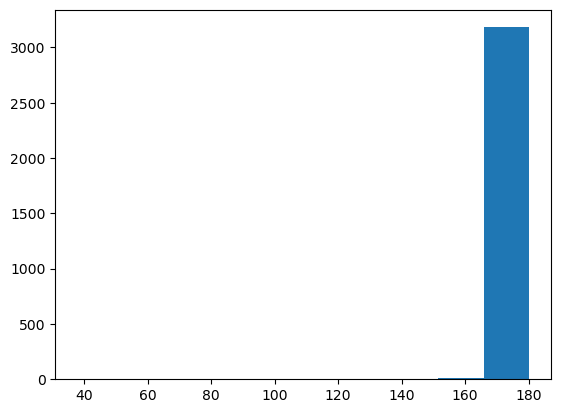

In [123]:
plt.hist(consumer_df['diff'])

In [96]:
transaction_df

,masked_consumer_id,posted_date,amount,category,masked_transaction_id,category_name,consumer_category,evaluation_date
0,C02103629,2022-08-12,-21.00,27,C02T02715977,HEALTHCARE_MEDICAL,2,2022-11-16
1,C02103629,2022-08-09,-8.60,22,C02T02715978,ESSENTIAL_SERVICES,2,2022-11-16
2,C02103629,2022-08-07,-30.05,16,C02T02715979,GENERAL_MERCHANDISE,2,2022-11-16
4,C02103629,2022-07-21,-50.00,12,C02T02715981,LOAN,2,2022-11-16
7,C02103629,2022-10-06,-15.33,1,C02T02715984,EXTERNAL_TRANSFER,2,2022-11-16
...,...,...,...,...,...,...,...,...
3002445,C02101790,2022-12-25,-2.95,19,C02T01330537,ATM_CASH,2,2023-05-02
3002451,C02101790,2023-04-14,-304.00,19,C02T01330543,ATM_CASH,2,2023-05-02
3002453,C02101790,2023-02-04,-225.72,16,C02T01330545,GENERAL_MERCHANDISE,2,2023-05-02
3002455,C02101790,2023-04-14,-10.00,15,C02T01330547,UNCATEGORIZED,2,2023-05-02


In [107]:
consumer_df

,evaluation_date,FPF_TARGET,total_balance,masked_consumer_id,consumer_category
0,2022-12-26,1.0,7.46,C02100001,2
1,2023-02-07,1.0,1689.96,C02100002,2
2,2023-07-13,0.0,11.01,C02100003,2
3,2022-12-02,1.0,6.96,C02100004,2
4,2022-10-28,0.0,0.00,C02100005,2
...,...,...,...,...,...
4995,2023-04-05,1.0,497.58,C02104996,2
4996,2023-02-09,1.0,290.50,C02104997,2
4997,2023-04-13,1.0,442.95,C02104998,2
4998,2023-02-02,0.0,10.89,C02104999,2


## Visualizing time series

In [98]:
def plot_ts_cat(consumer_id, category):
    df = transaction_df[(transaction_df['masked_consumer_id']==consumer_id) & (transaction_df['category']==category)]
    df = df.sort_values(by='posted_date')
    x = df['posted_date']
    y = df['amount']
    if len(y)==1:
        print(f'Category: {category,cat_map[category]}, single transaction: {y.iloc[0]}')
    elif len(y)>1:
        plt.plot(x,y)
        plt.title(f'Category: {category,cat_map[category]}')
        plt.show()
        print(f'Mean:{y.mean()}, Total: {y.sum()}')

def plot_ts(consumer_id):
    for cat in range(36):
        plot_ts_cat(consumer_id, cat)
    FPF_TARGET = consumer_df[consumer_df['masked_consumer_id']==consumer_id]['FPF_TARGET'].iloc[0]
    print(f'FPF_TARGET:{FPF_TARGET}')

def print_ts(consumer_id, category):
    df = transaction_df[(transaction_df['masked_consumer_id']==consumer_id) & (transaction_df['category']==category)]
    df = df.sort_values(by='posted_date')
    x = df['posted_date']
    y = df['amount']
    for date, amount in zip(x,y):
        print(date.date(), amount)

In [102]:
print_ts('C02100018', 16)

2023-01-28 -15.19
2023-01-28 -19.0
2023-01-28 -13.93
2023-01-29 -40.66
2023-02-04 -7.06
2023-02-06 -10.0
2023-02-07 -15.34
2023-02-11 -2.99
2023-02-13 -10.0
2023-02-14 -15.0
2023-02-14 -16.18
2023-02-14 -125.0
2023-02-15 -19.99
2023-02-15 -40.0
2023-02-15 -40.0
2023-02-17 -5.63
2023-02-18 -30.0
2023-02-20 -5.0
2023-02-24 -15.48
2023-02-24 -24.34
2023-03-01 -72.85
2023-03-02 -3.07
2023-03-02 -17.25
2023-03-02 -10.0
2023-03-02 -20.29
2023-03-02 -15.34
2023-03-03 -7.06
2023-03-03 -100.0
2023-03-04 -25.0
2023-03-04 -22.34
2023-03-04 -47.96
2023-03-06 -27.45
2023-03-06 -25.42
2023-03-06 -7.69
2023-03-06 -18.0
2023-03-06 -13.18
2023-03-07 -20.0
2023-03-07 -23.0
2023-03-07 -10.23
2023-03-07 -20.0
2023-03-08 -70.08
2023-03-08 -95.93
2023-03-08 -9.88
2023-03-08 -38.94
2023-03-08 -70.0
2023-03-09 -15.39
2023-03-09 -6.59
2023-03-09 -14.57
2023-03-09 -9.0
2023-03-09 -18.0
2023-03-09 -10.0
2023-03-09 -39.77
2023-03-10 -6.58
2023-03-10 -15.0
2023-03-10 -115.0
2023-03-10 -13.18
2023-03-10 -10.0
2023-

In [100]:
print_ts('C02100010', 3)

2022-11-23 1002.33
2022-12-08 15.85
2022-12-22 1447.37
2023-01-06 1420.89
2023-01-17 30.0
2023-01-19 1268.84
2023-02-02 956.24
2023-02-16 659.16
2023-03-02 476.97
2023-03-16 388.43
2023-03-30 761.1
2023-04-13 807.3
2023-04-27 918.49


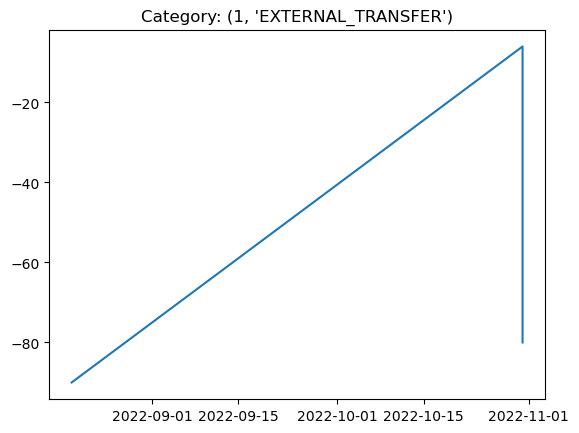

Mean:-58.666666666666664, Total: -176.0


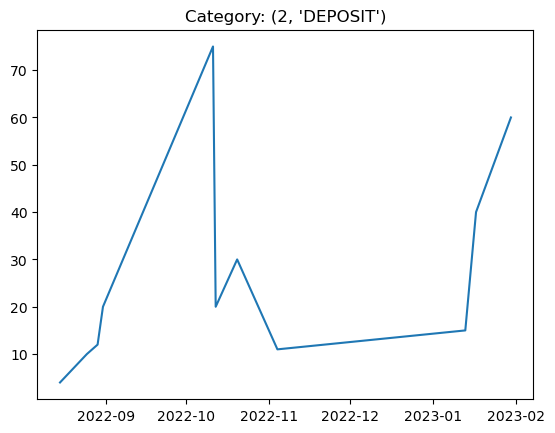

Mean:27.0, Total: 297.0


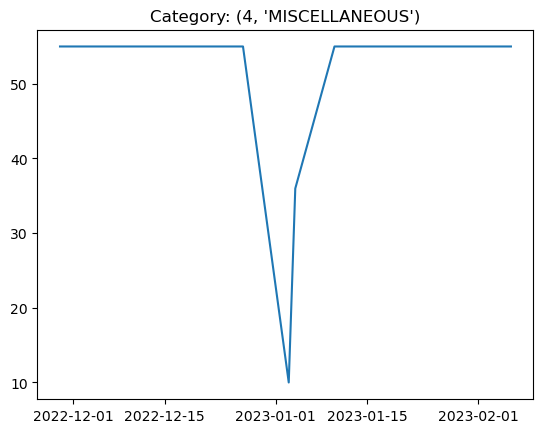

Mean:46.9975, Total: 375.98


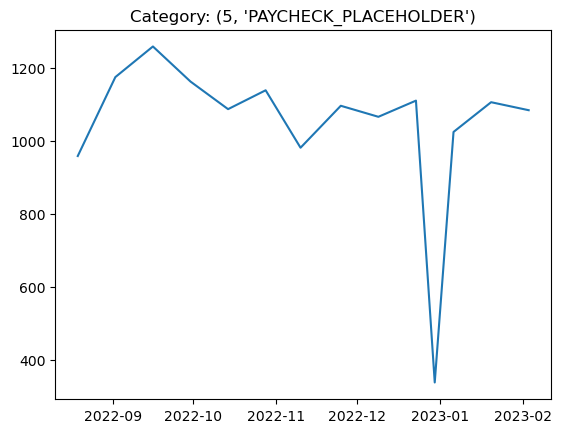

Mean:1041.722142857143, Total: 14584.11


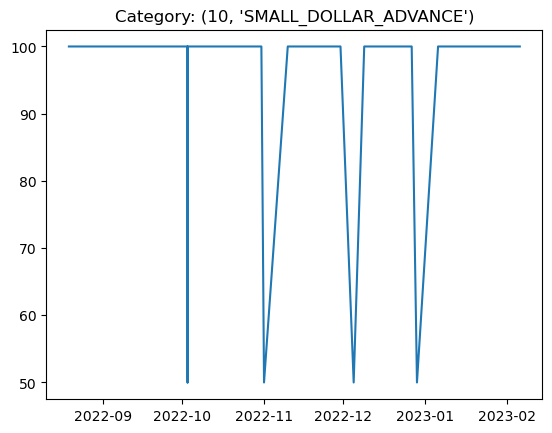

Mean:95.1219512195122, Total: 3900.0


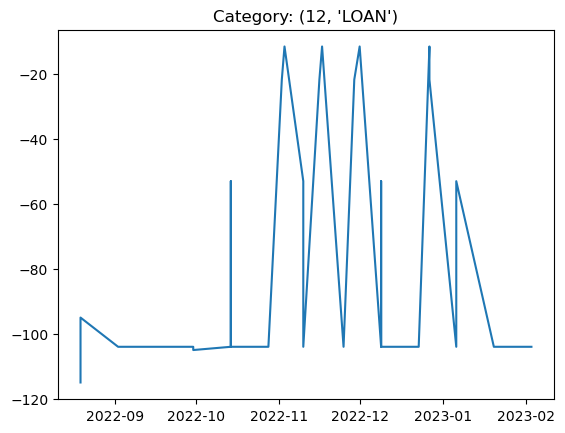

Mean:-85.98739999999998, Total: -4299.369999999999


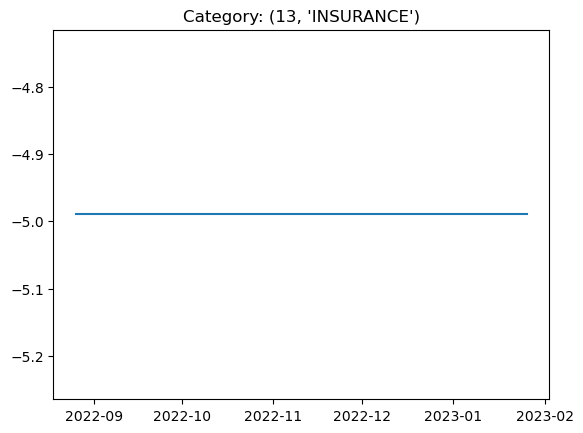

Mean:-4.990000000000001, Total: -29.940000000000005


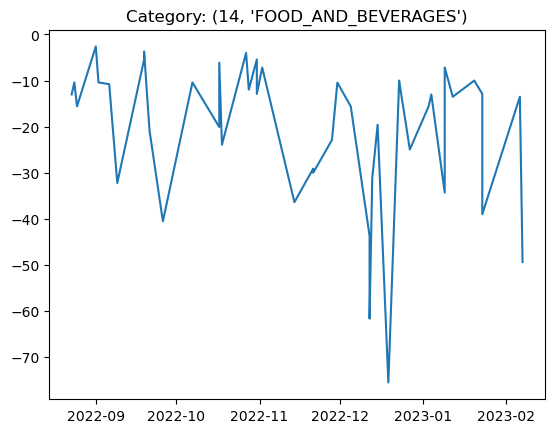

Mean:-20.161956521739132, Total: -927.45


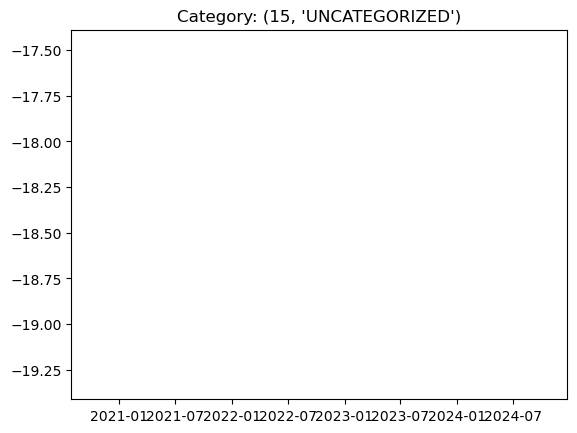

Mean:-18.4, Total: -55.199999999999996


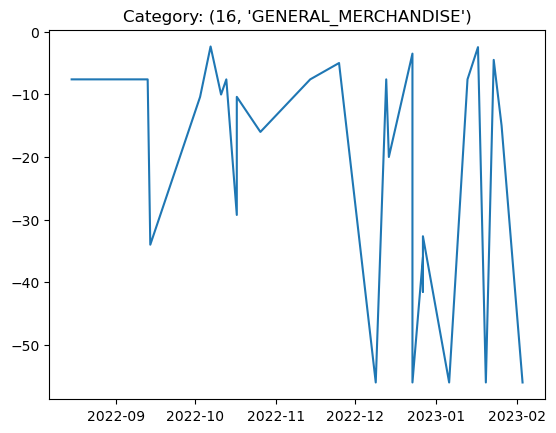

Mean:-22.171851851851855, Total: -598.6400000000001


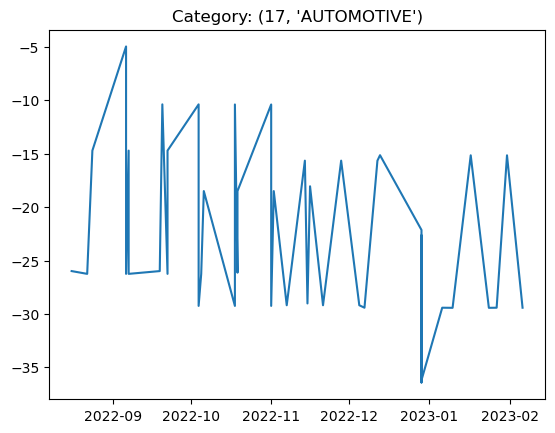

Mean:-22.423953488372092, Total: -964.2299999999999


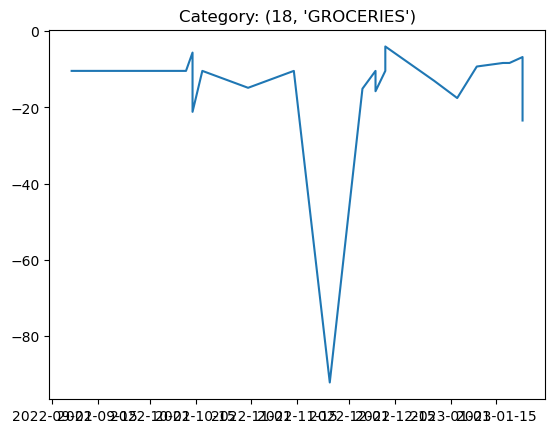

Mean:-15.882499999999997, Total: -317.6499999999999


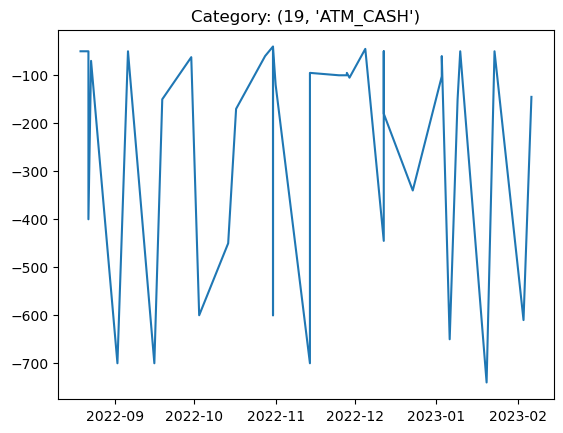

Mean:-231.91875, Total: -9276.75


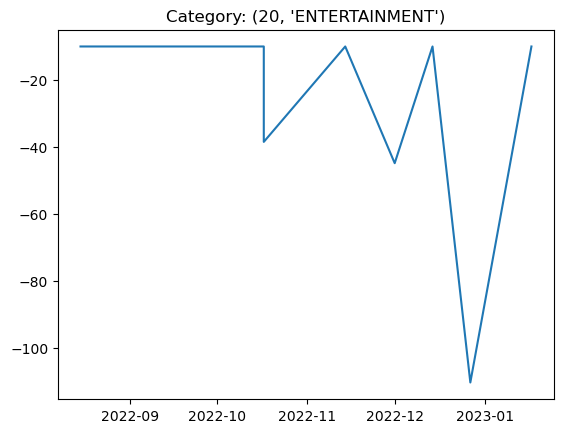

Mean:-28.17, Total: -253.53


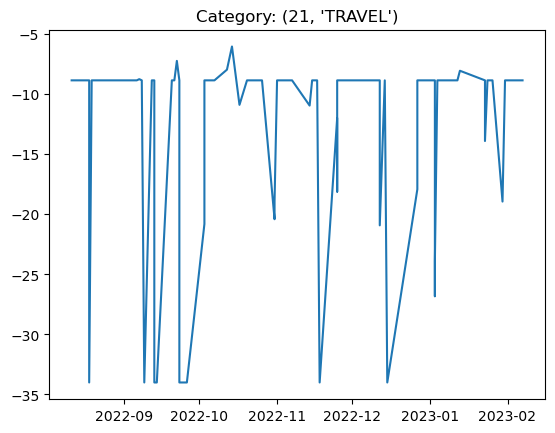

Mean:-12.869999999999996, Total: -1093.9499999999996


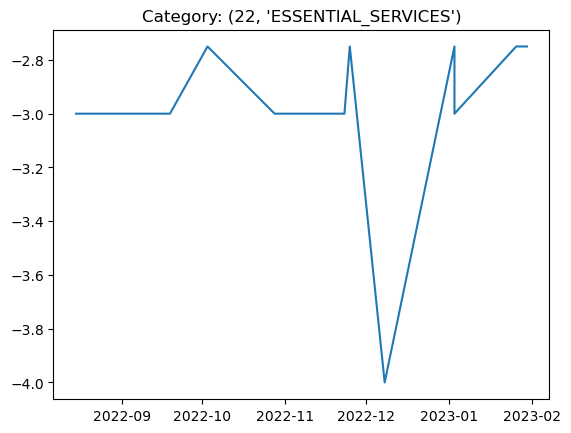

Mean:-2.966666666666667, Total: -44.5


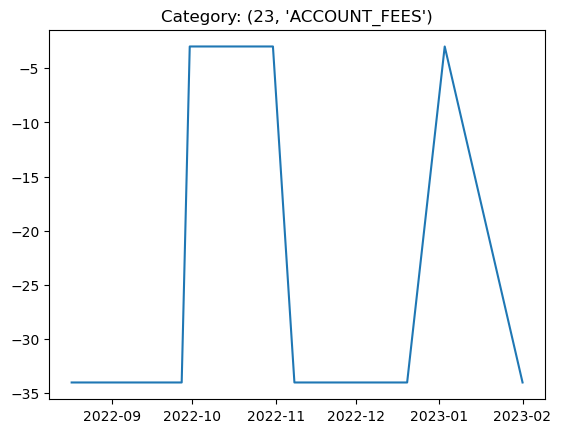

Mean:-29.772727272727273, Total: -655.0


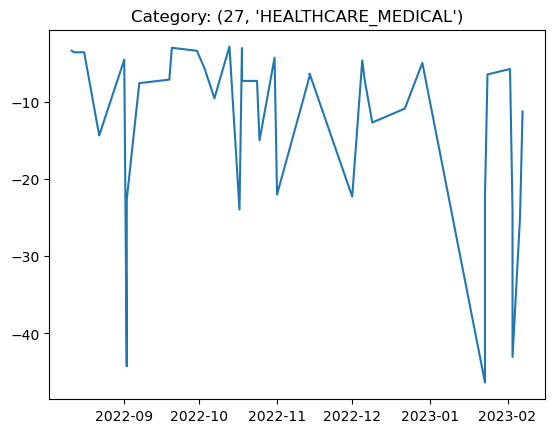

Mean:-12.923783783783785, Total: -478.18
FPF_TARGET:0.0


In [108]:
plot_ts('C02100060')